# Usage
This notebook provides essential guidance on how to use the core functionality of the `VeBNN` repo.




## 1. Dataset creation and loading 

Dataset is the only input required by this packages, this notebook shows how to create Dataset that matches data flow of the packages. 

- However create numerical problem
- Load the Plasticity law dataset

In [34]:
# import packages
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import warnings
warnings.filterwarnings("ignore")

### 1.1. Create numerical problem

Numerical function is one of the fast way to generate data to test a machine learning model. With this package, we provide this example to show how to set a numerical problem and how to prescribe noise accordingly.
 

In [10]:
def Xsin(x:torch.Tensor, train=False, noise_type: str= "homo") -> torch.Tensor:
    """ Xsin function with noise

    Parameters
    ----------
    x : torch.Tensor
        input tensor of the Xsin function
    train : bool, optional
        generating training or testing data, by default False
    noise_type : str, optional
        define the noise, by default "homo"

    Returns
    -------
    Responses
        responses of the input data points
    """
    if not train:
        return x * torch.sin(x)
    else:
        if noise_type == "heter":
            return x * torch.sin(x) + torch.abs(x) * torch.randn_like(x) * 0.3 + torch.randn_like(x) * 0.3
        elif noise_type == "homo":
            x * torch.sin(x) + torch.randn_like(x) * 0.5

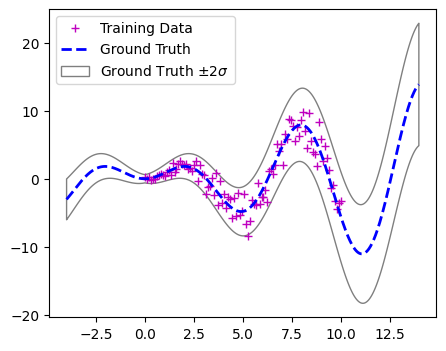

In [11]:
# generate data based on the defined function
samples = torch.linspace(0, 10, 100).reshape(-1, 1)
responses = Xsin(samples, train=True, noise_type="heter")
plot_samples = torch.linspace(-4, 14, 1400).reshape(-1, 1)
ground_truth = Xsin(plot_samples, train=False)


# plot the Xsin function
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(samples, responses, "m+", label="Training Data")
ax.plot(plot_samples, ground_truth,  "b--",
               linewidth=2, label="Ground Truth")
ax.fill_between(
        plot_samples.squeeze(),
        (ground_truth - 2*(torch.abs(plot_samples)*0.3 + 0.3)).squeeze(),
        (ground_truth + 2*(torch.abs(plot_samples)*0.3 + 0.3)).squeeze(),
        color="gray",
        edgecolor="black",
        facecolor="None",
        alpha=0.5,
        label=r"Ground Truth $\pm 2\sigma$",
    )   
plt.legend()
plt.show()


To this end, one can develop their own numerical case as following the same format. 

### 1.2. Plasticity Law Discovery Dataset


The fundamental mechanical law of materials is called a **constitutive law**. It relates average material **deformations** to average material **stresses** at any point in a structure. Constitutive laws can model different physics behaviors, such as **elasticity**, **hyperelasticity**, **plasticity**, and **damage**. In this dataset, we focus on generating datasets for **plastically deforming composite materials**, following prior work about Cooperative Data-Driven Modeling ([CDDM](https://www.sciencedirect.com/science/article/abs/pii/S004578252300556X)) . Without loss of generality, the constitutive law of such **path-dependent materials** can be written as:

$$
\mathbf{y} = f(\mathbf{x}, \dot{\mathbf{x}}, \tau, \dot{\tau}, \mathbf{h})
$$

where:

- $\mathbf{y}$ — stress  
- $\mathbf{x}$ — strain  
- $\tau$ — temperature  
- $\mathbf{h}$ — internal state variables  

These constitutive responses are predicted by **micro-scale FEM simulations** of material domains called **stochastic volume elements (SVEs)**. 

<div align="center">
    <img src="logo/sve_contour.png" alt="sve_contour" width="800"/>
</div>

Each SVE serves as a basic material simulation unit. Many factors introduce uncertainty in the data generation process. Here, we analyze two major sources:

1. **SVE size**  
2. **Particle distribution variability**  

Randomizing the particle distribution leads the resulting stress response for the same input deformation to exhibit **stochasticity (aleatoric uncertainty)**, which can observed with the `plot_test_function` of the `PlasticityLaw` class.

Two datasets are therefore generated from simulations according to the Table.

| Name       | $v_f$ | $r$    | $r_{\mathrm{std}}$ | Hardening Law                                  | $E_{\mathrm{fiber}}$ | Size   | $E_{\mathrm{matrix}}$ | $\nu_{\mathrm{matrix}}$ | $\nu_{\mathrm{fiber}}$ |
|-----------|-------|--------|--------------------|------------------------------------------------|----------------------|--------|------------------------|--------------------------|------------------------|
| Material 1 | 0.30  | 0.003  | 0.0                | $\sigma_{y} = 0.5 + 0.5(\bar{\epsilon})^{0.4}$ | 1                    | 0.048  | 100                    | 0.30                     | 0.19                   |
| Material 2 | 0.30  | 0.003  | 0.0                | $\sigma_{y} = 0.5 + 0.5(\bar{\epsilon})^{0.4}$ | 1                    | 0.030  | 100                    | 0.30                     | 0.19                   |






In [12]:
# import the corresponding function for Bayes datasets
from VeBNN.problems import PlasticityLaw

In [13]:
# load the dataset
plasticity_dataset = PlasticityLaw(dataset_path="plasticity_discovery/material_2_training_dataset.pickle",
                                  ground_truth=True,
                                  ground_truth_data_path="plasticity_discovery/material_2_testing_dataset.pickle")

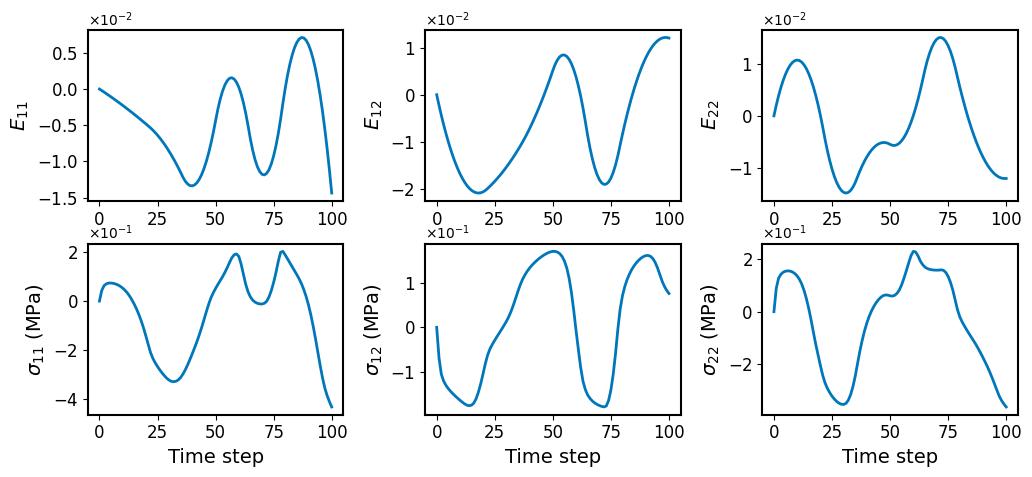

In [14]:
# visualization of the training data for specific index
plasticity_dataset.plot_training_data(index=0)

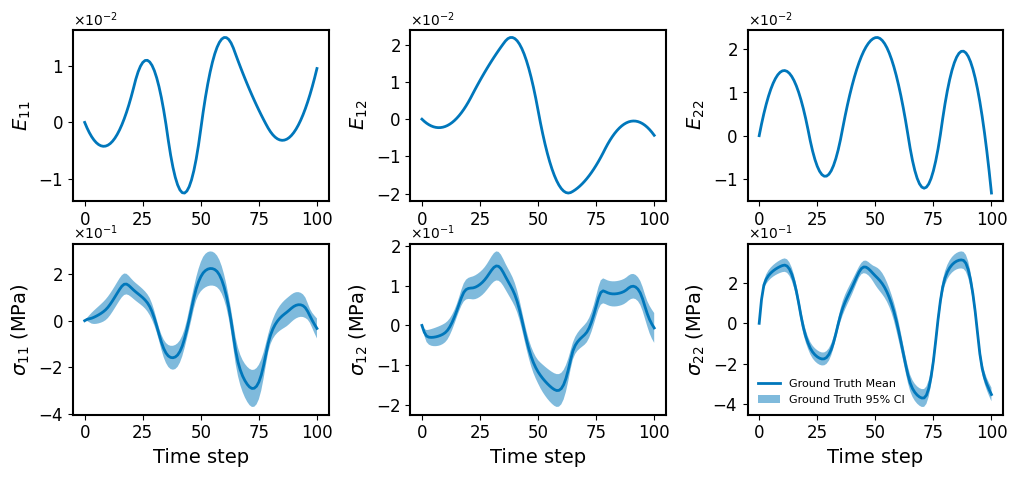

In [15]:
# visualize the test data with ground truth
plasticity_dataset.plot_test_data(index=2)

## 2. VeBNN training with one-dimensional illustrative example 
When you have tabular data, then you have to resort to Multi-layer perceptron or Feed-forward neural network to handle such problems. For example, in the [illustrative example] cell, we created a dataset with input `samples` and noisy observation `responses`. In order to handle such problem, we first need to define the neural architecture, and the assemble the `MeanNet` and `GammaVarNet`. With setting up for `MeanNet` and `GammaVarNet`, we can train the `VeBNN` method with MCMC method via `SGMCMCTrainer`. 

### 2.1. Create the MLP architecture and assemble it to mean and variance neural networks.

In [17]:
# import the necessary modules for VeBNN
from VeBNN.networks.mean_nets import MeanNet
from VeBNN.networks.variance_nets import GammaVarNet

In [19]:

# define the mean and variance networks
mean_mlp = nn.Sequential(
        nn.Linear(1, 64),
        nn.Tanh(),
        nn.Linear(64, 64),
        nn.Tanh(),
        nn.Linear(64, 1),
    )
mean_net = MeanNet(
    net=mean_mlp,
    prior_mu=0.0,
    prior_sigma=1.0,
)
variance_mlp = nn.Sequential(
    nn.Linear(1, 5),
    nn.Tanh(),
    nn.Linear(5, 2 * 1),  # notice the output is 2 * output_dim, since we need to output both alpha and beta
) # no softplus at the end, since it is already included in GammaVarNet
var_net = GammaVarNet(
    net=variance_mlp,
    prior_mu=0.0,
    prior_sigma=1.0,
)
# print the network structures
print(mean_net)
print(var_net)

MeanNet(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
GammaVarNet(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=5, bias=True)
    (1): Tanh()
    (2): Linear(in_features=5, out_features=2, bias=True)
  )
)


### 2.2. Assemble the SGMCMCTrainer, a implementation of VeBNN with SGMCMC inference methods.

In [21]:
# import the SGMCMC trainer
from VeBNN.methods.sgmcmc_trainer import SGMCMCTrainer

In [22]:
# ====== build trainer ======
trainer = SGMCMCTrainer(
    mean_net=mean_net, 
    var_net=var_net,
    device=torch.device("cpu"), # change to "cuda:0" if GPU is available
    job_id=1,  # any integer; used for temporary folder
)

# ====== configs (kept small so test is fast) ======
init_config = {
    "loss_name": "MSE",
    "optimizer_name": "Adam",
    "lr": 1e-3,
    "weight_decay": 1e-6,
    "num_epochs": 2000,      # warm-up epochs
    "batch_size": 64,
    "verbose": True,
    "print_iter": 50,
    "split_ratio": 0.8,
}

var_config = {
    "optimizer_name": "Adam",
    "lr": 1e-2,
    "num_epochs": 10000,
    "batch_size": 64,
    "verbose": True,
    "print_iter": 50,
    "early_stopping": False,
    "early_stopping_iter": 100,
    "early_stopping_tol": 1e-4,
}

sampler_config = {
    "sampler": "pSGLD",   # must match your VeBNN.samplers names
    "lr": 1e-3,
    "gamma": 0.9999,
    "num_epochs": 5000,    # SGMCMC epochs
    "mix_epochs": 100,     # thinning interval
    "burn_in_epochs": 1000,
    "batch_size": 64,
    "verbose": True,
    "print_iter": 100,
}

# ====== run cooperative training ======
# iteration controls how many outer loops (var <-> mean) you do.
# For a quick test, iteration=2 is enough to see if everything works.
trainer.cooperative_train(
    x_train=samples,
    y_train=responses,
    iteration=2,
    init_config=init_config,
    var_config=var_config,
    sampler_config=sampler_config,
    delete_model_raw_data=True,  # delete temporary folder after training
)



Epoch 1/2000, Train loss: 1.543e+01, Val loss: 1.787e+01
Epoch 50/2000, Train loss: 1.452e+01, Val loss: 1.635e+01
Epoch 100/2000, Train loss: 1.311e+01, Val loss: 1.396e+01
Epoch 150/2000, Train loss: 1.171e+01, Val loss: 1.245e+01
Epoch 200/2000, Train loss: 1.089e+01, Val loss: 1.089e+01
Epoch 250/2000, Train loss: 1.030e+01, Val loss: 1.020e+01
Epoch 300/2000, Train loss: 1.002e+01, Val loss: 9.685e+00
Epoch 350/2000, Train loss: 9.517e+00, Val loss: 9.483e+00
Epoch 400/2000, Train loss: 9.104e+00, Val loss: 8.895e+00
Epoch 450/2000, Train loss: 8.746e+00, Val loss: 8.573e+00
Epoch 500/2000, Train loss: 8.419e+00, Val loss: 8.083e+00
Epoch 550/2000, Train loss: 8.035e+00, Val loss: 7.873e+00
Epoch 600/2000, Train loss: 7.752e+00, Val loss: 7.582e+00
Epoch 650/2000, Train loss: 7.406e+00, Val loss: 7.190e+00
Epoch 700/2000, Train loss: 7.168e+00, Val loss: 7.017e+00
Epoch 750/2000, Train loss: 6.924e+00, Val loss: 6.709e+00
Epoch 800/2000, Train loss: 6.680e+00, Val loss: 6.529e+00


/home/yaga/Documents/GitHub/VeBNN/src/VeBNN/samplers/psgld.py:136: UserWarning: This overload of addcmul_ is deprecated:
	addcmul_(Number value, Tensor tensor1, Tensor tensor2)
Consider using one of the following signatures instead:
	addcmul_(Tensor tensor1, Tensor tensor2, *, Number value = 1) (Triggered internally at /pytorch/torch/csrc/utils/python_arg_parser.cpp:1805.)
  V.mul_(alpha).addcmul_(1 - alpha, d_p, d_p)


Epoch 100/5000, NLL: -1.418e+01, Neg log prior: 9.549e+03
Epoch 200/5000, NLL: -1.909e+01, Neg log prior: 1.006e+04
Epoch 300/5000, NLL: -1.352e+00, Neg log prior: 1.047e+04
Epoch 400/5000, NLL: -1.949e+01, Neg log prior: 1.079e+04
Epoch 500/5000, NLL: -2.854e+01, Neg log prior: 1.109e+04
Epoch 600/5000, NLL: -1.554e+01, Neg log prior: 1.135e+04
Epoch 700/5000, NLL: -2.251e+01, Neg log prior: 1.157e+04
Epoch 800/5000, NLL: -2.002e+01, Neg log prior: 1.184e+04
Epoch 900/5000, NLL: -2.343e+01, Neg log prior: 1.196e+04
Epoch 1000/5000, NLL: -1.907e+01, Neg log prior: 1.214e+04
Epoch 1100/5000, NLL: -3.168e+01, Neg log prior: 1.226e+04
Epoch 1200/5000, NLL: -4.309e+01, Neg log prior: 1.239e+04
Epoch 1300/5000, NLL: -3.698e+01, Neg log prior: 1.250e+04
Epoch 1400/5000, NLL: -2.872e+01, Neg log prior: 1.264e+04
Epoch 1500/5000, NLL: -2.932e+01, Neg log prior: 1.273e+04
Epoch 1600/5000, NLL: -2.873e+01, Neg log prior: 1.287e+04
Epoch 1700/5000, NLL: -3.887e+01, Neg log prior: 1.303e+04
Epoch 

### 2.3. Get predictions of the VeBNN with MLP 

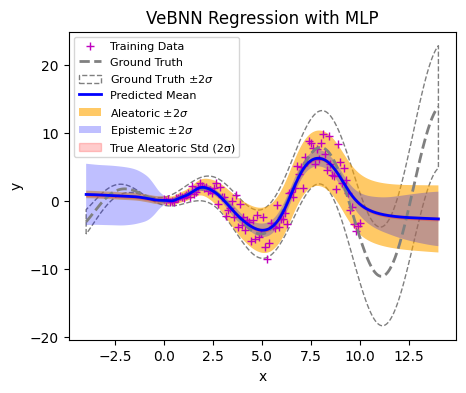

In [23]:
# get prediction for the plot_samples
pred_mean, pred_epistemic_var = trainer.bayes_predict(plot_samples)
pred_aleatoric_var = trainer.aleatoric_variance_predict(plot_samples)

fig, ax = plt.subplots(figsize=(5, 4))

ax.plot(samples, responses, "m+",  label="Training Data")
ax.plot(plot_samples, ground_truth,  "--", color="gray",
               linewidth=2, label="Ground Truth")
# plot ground truth with 2 std
ax.fill_between(
    plot_samples.squeeze(),
    (ground_truth - 2*(0.3+0.3*plot_samples )).squeeze(),
    (ground_truth + 2*(0.3+0.3*plot_samples)).squeeze(),
    color="gray",
    edgecolor="black",
    facecolor="None",
    linestyle="--",
    alpha=0.5,
    label=r"Ground Truth $\pm 2\sigma$",
)
# plot the prediction
ax.plot(plot_samples, pred_mean, color="b",
            linewidth=2,  label="Predicted Mean")
# plot the Aleatoric uncertainty
ax.fill_between(
    plot_samples.squeeze(),
    (pred_mean - 2*pred_aleatoric_var**0.5).squeeze(),
    (pred_mean + 2*pred_aleatoric_var**0.5).squeeze(),
    color="orange",
    alpha=0.6,
    edgecolor="None",
    label=r"Aleatoric $\pm 2\sigma$",

)
# plot the Epistemic uncertainty
ax.fill_between(
    plot_samples.squeeze(),
    (pred_mean - 2*pred_epistemic_var**0.5).squeeze(),
    (pred_mean + 2*pred_epistemic_var**0.5).squeeze(),
    color="blue",
    alpha=0.25,
    edgecolor="None",
    label=r"Epistemic $\pm 2\sigma$",

)
# plot the ground truth of aleatoric noise
y_true_ale_var = 0.1**2 * torch.ones_like(plot_samples)
y_true_ale_std = torch.sqrt(y_true_ale_var)
ax.fill_between(
    plot_samples.cpu().squeeze(),
    (pred_mean - 2 * y_true_ale_std).cpu().squeeze(),
    (pred_mean + 2 * y_true_ale_std).cpu().squeeze(),
    color='red', alpha=0.2, label='True Aleatoric Std (2σ)'
)
plt.title('VeBNN Regression with MLP')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(frameon=True, fontsize=8)
# plt.grid()
plt.show()



## 3. VeBNN training with plasticity law discovery dataset
In this part, I will should you to use VeBNN to learn the plasticity law discovery problem. In short, the `MeanNet`, `GammaVarNet`, and `SGMCMCTrainer` remain the same, since they can handle different architectures. However, since this dataset involves sequence-to-sequence problem, we need resort to the recurrent neural network architecture. 

### 3.1. Get training and testing samples from `PlasticityLaw`

In [24]:
# get the train, validate and test data
plasticity_dataset.get_train_val_split(num_train=100, num_val=100,)
# get the training, validate and test data
x_train_scaled, x_validate_scaled = plasticity_dataset.strain_train, plasticity_dataset.strain_validate
y_train_scaled, y_validate_scaled= plasticity_dataset.stress_train, plasticity_dataset.stress_validate
# get the ground truth data
plasticity_dataset.get_ground_truth()
# evaluate the model performance on ground truth data
strain_gt_scaled = plasticity_dataset.strain_ground_truth_normalized
stress_gt_mean_scaled = plasticity_dataset.stress_ground_truth_mean_normalized
stress_gt_std_scaled = plasticity_dataset.stress_ground_truth_std_normalized

### 3.2. Create GRU architecture with torch

In [25]:
# use torch to create a simple GRU model
class SimpleGRU(nn.Module):
    def __init__(self,
                 input_size: int,
                 hidden_size: int,
                 num_layers: int,
                 output_size: int,
                 bias: bool = True):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size,
                          hidden_size=hidden_size,
                          num_layers=num_layers,
                          bias=bias,
                          batch_first=True,
                        )  
        self.h2y = nn.Linear(hidden_size, output_size)

    def forward(self, x, hx=None):
        out, _ = self.gru(x, hx)      # (B, T, hidden_size)
        y = self.h2y(out)             # (B, T, output_size)
        return y


# define the mean and variance networks
mean_gru = SimpleGRU(input_size=3,
                         hidden_size=64,
                         num_layers=2,
                         output_size=3)
mean_network = MeanNet(net=mean_gru, 
                       prior_mu=0.0, 
                       prior_sigma=1.0)
# define the variance network
var_gru = SimpleGRU(input_size=3,
                        hidden_size=4,
                        num_layers=1,
                        output_size=6)
var_network = GammaVarNet(net=var_gru,
                            prior_mu=0.0,
                            prior_sigma=1.0)

# print the network structures
print(mean_network)
print(var_network)

MeanNet(
  (net): SimpleGRU(
    (gru): GRU(3, 64, num_layers=2, batch_first=True)
    (h2y): Linear(in_features=64, out_features=3, bias=True)
  )
)
GammaVarNet(
  (net): SimpleGRU(
    (gru): GRU(3, 4, batch_first=True)
    (h2y): Linear(in_features=4, out_features=6, bias=True)
  )
)


### 3.3. Assemble the SGMCMCTrainer for plasticity law discovery dataset

In [26]:
# set up the configuration for the VeBNN trainer
trainer = SGMCMCTrainer(mean_net=mean_network,
                          var_net=var_network,
                          device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                          job_id=1)
# ====== configs (kept small so test is fast) ======
init_config = {
    "loss_name": "MSE",
    "optimizer_name": "Adam",
    "lr": 1e-3,
    "weight_decay": 1e-6,
    "num_epochs": 100,      # warm-up epochs
    "batch_size": 64,
    "verbose": True,
    "print_iter": 50,
    "split_ratio": 0.8,
}

var_config = {
    "optimizer_name": "Adam",
    "lr": 1e-3,
    "num_epochs": 100,
    "batch_size": 64,
    "verbose": True,
    "print_iter": 50,
    "early_stopping": False,
    "early_stopping_iter": 100,
    "early_stopping_tol": 1e-4,
}

sampler_config = {
    "sampler": "pSGLD",   # must match your VeBNN.samplers names
    "lr": 1e-3,
    "gamma": 0.9999,
    "num_epochs": 200,    # SGMCMC epochs
    "mix_epochs": 10,     # thinning interval
    "burn_in_epochs": 100,
    "batch_size": 64,
    "verbose": True,
    "print_iter": 100,
}

# ====== run cooperative training ======
# For a quick test, iteration=2 is enough to see if everything works.
trainer.cooperative_train(
    x_train=x_train_scaled,
    y_train=y_train_scaled,
    iteration=1,
    init_config=init_config,
    var_config=var_config,
    sampler_config=sampler_config,
    delete_model_raw_data=True,  # delete temporary folder after training
)



/home/yaga/miniconda3/envs/vebnn_env/lib/python3.12/site-packages/torch/nn/modules/rnn.py:1394: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.gru(


Epoch 1/100, Train loss: 1.012e+00, Val loss: 1.011e+00
Epoch 50/100, Train loss: 1.370e-01, Val loss: 1.263e-01
Epoch 100/100, Train loss: 6.914e-02, Val loss: 6.242e-02
Step 2: Train for the variance network, iteration 1
Epoch/Total: 0/100, Gamma NLL: -1.146e+04, neg log prior: 1.317e+02, log marginal likelihood: 0.000e+00
Epoch/Total: 50/100, Gamma NLL: -2.229e+04, neg log prior: 1.318e+02, log marginal likelihood: 0.000e+00
Finished training the variance network
Step 3: Train for the mean network with SGMCMC
Epoch 100/200, NLL: -8.440e+04, Neg log prior: 7.431e+04
Epoch 200/200, NLL: -8.434e+04, Neg log prior: 7.622e+04
Finished training the Bayesian mean network
Create model data folder to save the temporary models
Finished training the model
Delete the model data folder to free space


### 3.4. Get predictions for the plasticity law dataset

In [27]:
# get the prediction from the bnn
pred, var_epistemic = trainer.bayes_predict(x=strain_gt_scaled)
# for aleatoric uncertainty
var_aleatoric= trainer.aleatoric_variance_predict(
    x=strain_gt_scaled)
# convert to cpu 
pred = pred.cpu().detach()
var_epistemic = var_epistemic.cpu().detach()
var_aleatoric = var_aleatoric.cpu().detach()
# set the 
# scale the prediction back
pred = pred * plasticity_dataset.stress_std + plasticity_dataset.stress_mean
var_epistemic = var_epistemic * plasticity_dataset.stress_std ** 2
var_aleatoric = var_aleatoric * plasticity_dataset.stress_std ** 2

In [32]:
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))

def prediction_plot(
    x_test: torch.Tensor,
    y_test: torch.Tensor,
    y_pred_mean: torch.Tensor,
    y_pred_var: torch.Tensor,
    y_pred_aleatoric: torch.Tensor,
    index: int,
    fig_name="rnn_prediction",
    save_fig: bool = False,
    y_test_var: torch.Tensor = None,
) -> None:

    strain = x_test.cpu().detach().numpy()
    stress = y_test.cpu().detach().numpy()
    y_pred_mean = y_pred_mean.cpu().detach().numpy()
    if y_pred_var is not None:
        y_pred_var = y_pred_var.cpu().detach().numpy()
    if y_test_var is not None:
        y_test_var = y_test_var.cpu().detach().numpy()
    if y_pred_aleatoric is not None:
        y_pred_aleatoric = y_pred_aleatoric.cpu().detach().numpy()

    fig, ax = plt.subplots(2, 3, figsize=(12, 5))

    ax[0, 0].plot(strain[index, :, 0], "-", color="#0077BB", linewidth=2)
    ax[0, 0].set_ylabel(ylabel=r"$E_{11}$", fontsize=12)
    ax[0, 0].yaxis.set_major_formatter(formatter)
    ax[0, 1].plot(strain[index, :, 1], "-", color="#0077BB", linewidth=2)
    ax[0, 1].set_ylabel(ylabel=r"$E_{12}$", fontsize=12)
    ax[0, 1].yaxis.set_major_formatter(formatter)
    ax[0, 2].plot(strain[index, :, 2], "-", color="#0077BB", linewidth=2)
    ax[0, 2].set_ylabel(ylabel=r"$E_{22}$", fontsize=12)
    ax[0, 2].yaxis.set_major_formatter(formatter)

    # plot the stress
    ax[1, 0].plot(stress[index, :, 0], "-", linewidth=2, color="#0077BB")
    if y_test_var is not None:
        ax[1, 0].fill_between(
            range(len(stress[index, :, 0])),
            y1=y_test[index, :, 0] - 2 * np.sqrt(y_test_var[index, :, 0]),
            y2=y_test[index, :, 0] + 2 * np.sqrt(y_test_var[index, :, 0]),
            edgecolor="none",
            color="#0077BB",
            alpha=0.3,
        )
    ax[1, 0].plot(y_pred_mean[index, :, 0], "-", color="#CC3311", linewidth=2)
    if y_pred_var is not None:
        ax[1, 0].fill_between(
            range(len(stress[index, :, 0])),
            y1=y_pred_mean[index, :, 0] - 2 * np.sqrt(y_pred_var[index, :, 0]),
            y2=y_pred_mean[index, :, 0] + 2 * np.sqrt(y_pred_var[index, :, 0]),
            edgecolor="none",
            color="#EE7733",
            alpha=0.5,
        )
    # plot the aleatoric uncertainty
    if y_pred_aleatoric is not None:
        ax[1, 0].fill_between(
            range(len(stress[index, :, 0])),
            y1=y_pred_mean[index, :, 0] - 2 *
            np.sqrt(y_pred_aleatoric[index, :, 0]),
            y2=y_pred_mean[index, :, 0] + 2 *
            np.sqrt(y_pred_aleatoric[index, :, 0]),
            alpha=0.6,
            color="gray",
            edgecolor="none",
        )

    ax[1, 0].set_xlabel(xlabel="Time step", fontsize=12)
    ax[1, 0].set_ylabel(ylabel=r"$\sigma_{11}$ (MPa)", fontsize=12)
    ax[1, 0].yaxis.set_major_formatter(formatter)
    ax[1, 1].plot(
        stress[index, :, 1],
        "-",
        linewidth=2,
        color="#0077BB",
    )
    if y_test_var is not None:
        ax[1, 1].fill_between(
            range(len(stress[index, :, 1])),
            y1=y_test[index, :, 1] - 2 * np.sqrt(y_test_var[index, :, 1]),
            y2=y_test[index, :, 1] + 2 * np.sqrt(y_test_var[index, :, 1]),
            edgecolor="none",
            color="#0077BB",
            alpha=0.3,
        )
    ax[1, 1].plot(
        y_pred_mean[index, :, 1],
        "-",
        color="#CC3311",
        linewidth=2,
    )
    if y_pred_var is not None:
        ax[1, 1].fill_between(
            range(len(stress[index, :, 1])),
            y1=y_pred_mean[index, :, 1] - 2 * np.sqrt(y_pred_var[index, :, 1]),
            y2=y_pred_mean[index, :, 1] + 2 * np.sqrt(y_pred_var[index, :, 1]),
            color="#EE7733",
            edgecolor="none",
            alpha=0.5,
        )
    # plot the aleatoric uncertainty
    if y_pred_aleatoric is not None:
        ax[1, 1].fill_between(
            range(len(stress[index, :, 1])),
            y1=y_pred_mean[index, :, 1] - 2 *
            np.sqrt(y_pred_aleatoric[index, :, 1]),
            y2=y_pred_mean[index, :, 1] + 2 *
            np.sqrt(y_pred_aleatoric[index, :, 1]),
            alpha=0.3,
            color="gray",
            edgecolor="none",
        )
    ax[1, 1].set_ylabel(ylabel=r"$\sigma_{12}$ (MPa)", fontsize=12)
    ax[1, 1].set_xlabel(xlabel="Time step", fontsize=12)

    ax[1, 1].yaxis.set_major_formatter(formatter)

    if y_test_var is not None:
        ax[1, 2].plot(
            stress[index, :, 2], "-", linewidth=2, color="#0077BB", label="Ground Truth Mean"
        )
        ax[1, 2].fill_between(
            range(len(stress[index, :, 2])),
            y1=y_test[index, :, 2] - 2 * np.sqrt(y_test_var[index, :, 2]),
            y2=y_test[index, :, 2] + 2 * np.sqrt(y_test_var[index, :, 2]),
            edgecolor="none",
            color="#0077BB",
            alpha=0.5,
            label="Ground Truth 95% CI",
        )
    else:
        ax[1, 2].plot(
            stress[index, :, 2], "-", linewidth=2, color="#0077BB", label="Test Data"
        )

    ax[1, 2].plot(
        y_pred_mean[index, :, 2], "-", color="#CC3311", linewidth=2, label="Pred. Mean"
    )
    if y_pred_var is not None:
        ax[1, 2].fill_between(
            range(len(stress[index, :, 2])),
            y1=y_pred_mean[index, :, 2] - 2 * np.sqrt(y_pred_var[index, :, 2]),
            y2=y_pred_mean[index, :, 2] + 2 * np.sqrt(y_pred_var[index, :, 2]),
            alpha=0.3,
            color="#EE7733",
            edgecolor="none",
            label="Pred. 95% CI Total",
        )
    # plot the aleatoric uncertainty
    if y_pred_aleatoric is not None:
        ax[1, 2].fill_between(
            range(len(stress[index, :, 2])),
            y1=y_pred_mean[index, :, 2] - 2 *
            np.sqrt(y_pred_aleatoric[index, :, 2]),
            y2=y_pred_mean[index, :, 2] + 2 *
            np.sqrt(y_pred_aleatoric[index, :, 2]),
            alpha=0.3,
            color="gray",
            edgecolor="none",
            label="Pred. 95% CI Aleatoric",
        )

    ax[1, 2].set_xlabel(xlabel="Time step", fontsize=12)
    ax[1, 2].set_ylabel(ylabel=r"$\sigma_{22}$ (MPa)", fontsize=12)
    ax[1, 2].legend(fontsize=8, loc="best", frameon=False)
    ax[1, 2].yaxis.set_major_formatter(formatter)

    # set the line width  and font size for the axises
    for i in range(2):
        for j in range(3):
            ax[i, j].tick_params(axis="both", which="major", labelsize=12)
            # set linewidth
            for axis in ["top", "bottom", "left", "right"]:
                ax[i, j].spines[axis].set_linewidth(1.5)
    # set the spaces for subplots
    plt.subplots_adjust(wspace=0.32, hspace=0.25)

    if save_fig:
        # plt.savefig(f"{fig_name}.pdf", dpi=300, bbox_inches="tight")
        plt.savefig(f"{fig_name}.png", dpi=300, bbox_inches="tight")
    else:
        plt.show()


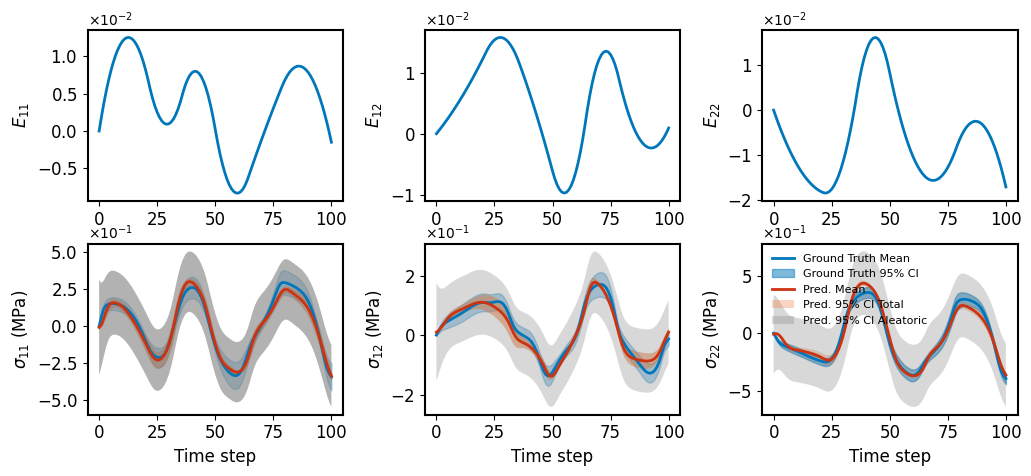

In [35]:
prediction_plot(
        x_test=plasticity_dataset.strain_ground_truth,
        y_test=plasticity_dataset.stress_ground_truth_mean,
        y_pred_mean=pred,
        y_pred_var=var_epistemic,
        y_pred_aleatoric=var_aleatoric,
        index=1,
        save_fig=False,
        y_test_var=plasticity_dataset.stress_ground_truth_std**2,
    )

**have fun!**